In [6]:
# Data loading, filtering, splitting, and normalization (reference: test_fusion.py & test_gine.py)
import torch
import numpy as np
from torch_geometric.data import DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset with mol_index
data_list = torch.load('../data/raw/zinc_pyg_dataset_with_index.pt')

# Load KG embeddings
kg_embeddings = torch.load('../embeddings/kg_embeddings.pt')
kg_molecule_embeddings = kg_embeddings['molecule']
N = kg_molecule_embeddings.shape[0]

# Filter dataset: keep only Data objects with valid mol_index
filtered_data_list = [d for d in data_list if d.mol_index.item() < N]

# Extract logP target (column 1)
for data in filtered_data_list:
    if data.y.dim() > 0:
        logp = data.y[1].item()
    else:
        logp = float(data.y)
    data.y = torch.tensor([logp], dtype=torch.float)

# Split dataset (80/10/10)
n_total = len(filtered_data_list)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val
indices = np.arange(n_total)
np.random.seed(42)
np.random.shuffle(indices)
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]
train_set = [filtered_data_list[i] for i in train_idx]
val_set = [filtered_data_list[i] for i in val_idx]
test_set = [filtered_data_list[i] for i in test_idx]

# Compute normalization stats from train_set only
def compute_normalization(dataset):
    y = torch.cat([data.y for data in dataset]).view(-1)
    mean = y.mean().item()
    std = y.std().item()
    return mean, std
def denormalize(tensor, mean, std):
    return tensor * std + mean
mean, std = compute_normalization(train_set)
print(f'Target normalization: mean={mean:.6f}, std={std:.6f}')

# Normalize targets for all splits
for dataset in [train_set, val_set, test_set]:
    for data in dataset:
        data.y = (data.y - mean) / std

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)


C:\Users\rhyth\AppData\Local\Temp\ipykernel_29440\574647786.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_list = torch.load('../data/raw/zinc_pyg_dataset_with_in

Target normalization: mean=2.825956, std=1.161189


C:\Users\rhyth\AppData\Local\Temp\ipykernel_29440\574647786.py:61: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=False)
C:\Users\rhyth\AppData\Local\Temp\ipykernel_29440\574647786.py:62: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
C:\Users\rhyth\AppData\Local\Temp\ipykernel_29440\574647786.py:63: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)


In [14]:
import sys
sys.path.append("..")

from src.fusion_model import FusionModel
from src.train_gine import GINEModel

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load pretrained GINE model (for Fusion backbone)
gine_model = GINEModel(
    node_feat_dim=train_set[0].x.shape[1],
    edge_feat_dim=train_set[0].edge_attr.shape[1],
    num_atom_types=int(torch.max(torch.cat([data.x[:, 0] for data in train_set])).item()) + 1,
    emb_dim=64,
    hidden_dim=256,
    dropout=0.25
).to(device)
gine_model.load_state_dict(torch.load('../models/best_gine_model.pt', map_location=device))
gine_model.eval()

# Load pretrained FusionModel
fusion_model = FusionModel(gine_model, kg_molecule_embeddings, freeze_gine=True, mlp_hidden=128).to(device)
fusion_model.load_state_dict(torch.load('../models/best_fusion_model.pt', map_location=device))
fusion_model.eval()

# Evaluation function for Fusion
def evaluate_fusion(model, loader, kg_molecule_embeddings, mean, std):
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            mol_indices = batch.mol_index.to(device)
            valid_mask = mol_indices < kg_molecule_embeddings.shape[0]
            if not torch.all(valid_mask):
                from torch_geometric.data import Batch
                batch_list = batch.to_data_list()
                filtered_batch_list = [batch_list[i] for i, v in enumerate(valid_mask) if v]
                batch = Batch.from_data_list(filtered_batch_list)
                mol_indices = mol_indices[valid_mask]
            pred = model(batch, mol_indices)
            current_batch_size = batch.num_graphs
            if batch.y.shape[0] == current_batch_size * 5:
                target = batch.y.view(current_batch_size, 5)[:, 1]
            elif len(batch.y.shape) == 2 and batch.y.shape[1] == 5:
                target = batch.y[:, 1]
            else:
                target = batch.y.view(-1)
            y_true.append(denormalize(target.cpu(), mean, std))
            y_pred.append(denormalize(pred.cpu(), mean, std))
    y_true = torch.cat(y_true)
    y_pred = torch.cat(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse, y_true, y_pred

fusion_mae, fusion_rmse, fusion_y_true, fusion_y_pred = evaluate_fusion(fusion_model, test_loader, kg_molecule_embeddings, mean, std)
print(f'Fusion Test MAE: {fusion_mae:.4f}, RMSE: {fusion_rmse:.4f}')


C:\Users\rhyth\AppData\Local\Temp\ipykernel_29440\1255194994.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gine_model.load_state_dict(torch.load('../models/best_gine_

Fusion Test MAE: 0.0846, RMSE: 0.1177


In [15]:
# GINE model evaluation (reference: test_gine.py)
from src.train_gine import GINEModel

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load pretrained GINE model
gine_model = GINEModel(
    node_feat_dim=train_set[0].x.shape[1],
    edge_feat_dim=train_set[0].edge_attr.shape[1],
    num_atom_types=int(torch.max(torch.cat([data.x[:, 0] for data in train_set])).item()) + 1,
    emb_dim=64,
    hidden_dim=256,
    dropout=0.25
).to(device)
gine_model.load_state_dict(torch.load('../models/best_gine_model.pt', map_location=device))
gine_model.eval()

# Evaluation function for GINE
def evaluate_gine(model, loader, mean, std):
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            target = batch.y.view(-1)
            y_true.append(denormalize(target.cpu(), mean, std))
            y_pred.append(denormalize(pred.cpu(), mean, std))
    y_true = torch.cat(y_true)
    y_pred = torch.cat(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse, y_true, y_pred

gine_mae, gine_rmse, gine_y_true, gine_y_pred = evaluate_gine(gine_model, test_loader, mean, std)
print(f'GINE Test MAE: {gine_mae:.4f}, RMSE: {gine_rmse:.4f}')


C:\Users\rhyth\AppData\Local\Temp\ipykernel_29440\3619643803.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gine_model.load_state_dict(torch.load('../models/best_gine_

GINE Test MAE: 0.1333, RMSE: 0.1581


--- Comparative Analysis ---
Fusion Test MAE: 0.0846, RMSE: 0.1177
GINE   Test MAE: 0.1333, RMSE: 0.1581
Fusion improvement (MAE): 0.0488


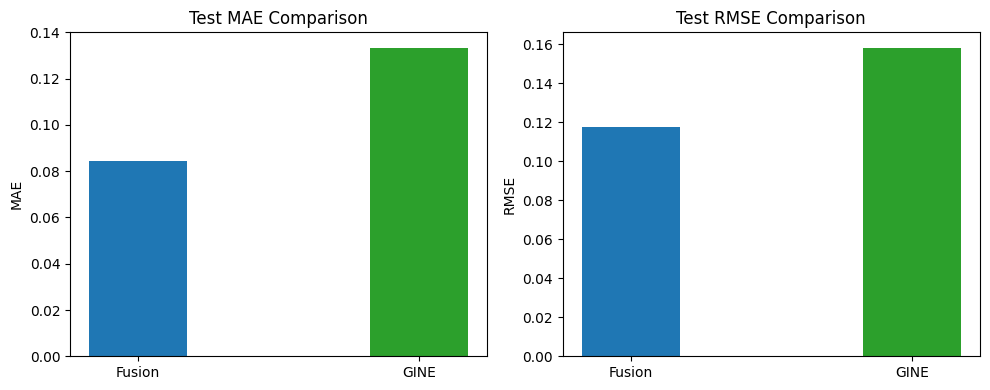

In [16]:
# Comparative Analysis of Fusion and GINE Models (MAE & RMSE)
import matplotlib.pyplot as plt
import numpy as np
print('--- Comparative Analysis ---')
print(f'Fusion Test MAE: {fusion_mae:.4f}, RMSE: {fusion_rmse:.4f}')
print(f'GINE   Test MAE: {gine_mae:.4f}, RMSE: {gine_rmse:.4f}')
print(f'Fusion improvement (MAE): {gine_mae - fusion_mae:.4f}')

# Bar plot for MAE and RMSE
labels = ['Fusion', 'GINE']
mae_scores = [fusion_mae, gine_mae]
rmse_scores = [fusion_rmse, gine_rmse]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(x, mae_scores, width, color=['#1f77b4', '#2ca02c'])
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].set_ylabel('MAE')
ax[0].set_title('Test MAE Comparison')
ax[1].bar(x, rmse_scores, width, color=['#1f77b4', '#2ca02c'])
ax[1].set_xticks(x)
ax[1].set_xticklabels(labels)
ax[1].set_ylabel('RMSE')
ax[1].set_title('Test RMSE Comparison')
plt.tight_layout()
plt.show()
